---
title: "ASM1: a stoichiometric matrix that checks itself"
description: "The activated sludge model is 8 processes and 13 components arranged in a Petersen matrix. Read it off the 1987 page and the continuity relations that the component definitions force turn out to close exactly - charge and nitrogen to machine precision, COD everywhere except two cells, where the residual is exactly the rounding of 20/7 to 2.86 and 32/7 to 4.57."
categories: [sec:J, struct:S1, tier:T1, data:tier2, phase:liquid]
date: 2026-07-30
---

# ASM1: a stoichiometric matrix that checks itself

**Catalog ID:** `J4.8` · **Structures:** `S1` (reaction network) · **Tier:** T1

The IAWPRC Activated Sludge Model No. 1 is the most widely used model in
environmental engineering, and it is not a set of differential equations. It is
**one table** — eight biological processes down the side, thirteen components
across the top, and a stoichiometric coefficient in each box.

That table has a property most published kinetic schemes do not: it is
**self-checking**. The components are declared in units of COD, of nitrogen, and
of ionic charge, and those declarations force three conservation relations on
every row. Reproducing the matrix and then testing whether continuity closes is a
much stronger validation than fitting any curve — it either works to machine
precision or it does not, and there is no tolerance to negotiate.

It closes. And where it does not, the discrepancy turns out to be exactly the
two-decimal rounding of two conversion factors printed in the table.

## Background

A single-sludge plant does three jobs at once. Heterotrophs oxidise organic
carbon, using oxygen where it is available and nitrate where it is not.
Autotrophs oxidise ammonia to nitrate, but only aerobically. And the sludge
itself decays, releasing substrate and nitrogen back into the liquid. The
processes compete for the same electron acceptors in the same tank, which is why
the task group formed in 1983 set out to find the simplest model still capable of
realistic predictions for single-sludge systems.

What they produced is presented in the **matrix format of Petersen (1965)**:
components across the top, processes down the side, and a rate expression on the
right. The observed conversion rate of any component is then one column sum,

$$ r_i = \sum_j \nu_{ij}\,\rho_j $$

which is the paper's equation (1). This is not a presentational convenience. The
matrix layout makes the stoichiometry inspectable in a way that a list of ODEs
never is, and it makes the conservation checks below possible at all.

**Why the units matter more than they look.** The paper insists on three
conventions and then says why:

- every organic component is in **COD**, so "calculation of the oxygen
  requirement by a simple COD balance" becomes possible;
- every nitrogen species is expressed **as N**, so the two conversion factors
  2.86 and 4.57 are needed "to convert nitrate nitrogen and ammonia nitrogen
  concentrations, respectively, to an equivalent COD basis";
- alkalinity is in **molar units**, included so that "undue changes in pH can be
  predicted and avoided" — the paper's threshold is 50 g m⁻³ as CaCO₃, below
  which "the pH becomes unstable and can fall to values well below 6".

Those three conventions are exactly what makes the matrix testable. Each one
defines a linear functional on the component vector, and each such functional
must annihilate every row of the matrix.

## The published model

**Thirteen components.** Seven in COD units ($S_I$, $S_S$, $X_I$, $X_S$,
$X_{B,H}$, $X_{B,A}$, $X_P$), oxygen as *negative* COD ($S_O$), four nitrogen
species ($S_{NO}$, $S_{NH}$, $S_{ND}$, $X_{ND}$), and alkalinity ($S_{ALK}$).

**Eight processes.** Aerobic and anoxic growth of heterotrophs; aerobic growth of
autotrophs; decay of each biomass; ammonification; and hydrolysis of entrapped
organics and of entrapped organic nitrogen.

The whole of Table 1 — every stoichiometric coefficient and every rate
expression — is transcribed into `data/` and loaded below rather than retyped
into the notebook. **Nothing came from the PDF text layer**, which scrambles the
matrix completely: it renders $1/Y_H$ as `I / r~`, $(4.57-Y_A)/Y_A$ as
`4 . 5 7 - Y4 / Y,~`, and drops most of the alkalinity column. Both journal
pages were rendered at 600 dpi and read as images.

**The three continuity relations.** These are *not* printed in the paper — this
is the abbreviated report, and it states the conventions but never writes the
balances out. They follow from the component definitions alone. Assign each
component its content of a conserved quantity and require

$$ \sum_i \gamma_i \,\nu_{ij} = 0 \qquad\text{for every process } j $$

for $\gamma$ = theoretical oxygen demand, nitrogen, and ionic charge.

| $\gamma$ | how the paper fixes it |
|---|---|
| **COD** | $+1$ for the seven organic components (declared in COD units), $-1$ for $S_O$ ("oxygen, negative COD"), $0$ for $S_{NH}$, $S_{ND}$, $X_{ND}$ and $S_{ALK}$ |
| **N** | $1$ for the four nitrogen species (all "given as nitrogen"), $i_{XB}$ for both biomasses and $i_{XP}$ for $X_P$ (the paper's own definitions of those two parameters) |
| **charge** | $+1/14$ for $S_{NH}$ (NH₄⁺, per g N), $-1/14$ for $S_{NO}$ (NO₃⁻), $-1$ for $S_{ALK}$ (alkalinity in molar units) |

Only $\gamma_\text{COD}(S_{NO})$ takes any thought, and the paper hands it over
too. Fix the reference oxidation state of nitrogen at $-\mathrm{III}$ — ammonium
and organic amine — because that is what dichromate COD measures. Then, per gram
of N,

$$\gamma_\text{COD}(S_{NH}) = 0,\qquad
  \gamma_\text{COD}(S_{N_2}) = -\tfrac{24}{14} = -\tfrac{12}{7},\qquad
  \gamma_\text{COD}(S_{NO}) = -\tfrac{64}{14} = -\tfrac{32}{7}. $$

**The paper's own two conversion factors are two differences on that one scale:**

$$ \underbrace{\tfrac{32}{7} - \tfrac{12}{7} = \tfrac{20}{7} = 2.857\ldots}_{\text{nitrate}\to\text{N}_2,\ \text{the printed }2.86}
\qquad
\underbrace{\tfrac{32}{7} - 0 = \tfrac{32}{7} = 4.571\ldots}_{\text{ammonium}\to\text{nitrate},\ \text{the printed }4.57} $$

That is the whole reason a single COD continuity can cover both denitrification
and nitrification, and it is the point on which everything below turns.

## Parameters and assumptions

**The continuity check needs no parameters at all.** It is an identity in the
five stoichiometric symbols $Y_H$, $Y_A$, $f_P$, $i_{XB}$, $i_{XP}$, and it is
verified symbolically below, not at a sample point. Table 4's numbers are needed
only for the illustrative reactor.

**Dinitrogen is not a component of ASM1, and it has to be.** The model tracks
$S_{NO}$ but the nitrogen leaving as N₂ gas goes nowhere, so nitrogen continuity
cannot possibly close on process 2 as printed. This page therefore carries a
fourteenth component $S_{N_2}$ with $\nu_{2,N_2} = -\nu_{2,NO}$, which is the
only addition made to the published matrix anywhere on this page. It affects
nothing else — no rate expression reads it — and later models (ASM2, ASM3) add
it for exactly this reason.

**A defect in Table 4, reported rather than repaired.** The paper says the model
"contains 13 components and 19 parameters", and Table 1's own parameter lists
name exactly nineteen. **Table 4 prints twenty rows.** The extra one is a second
ammonification coefficient: $k_a = 0.016$ m³(g cell COD·day)⁻¹ sits in the right
place in the kinetic block, and $k_A = 0.08$ m³ COD (g·day)⁻¹ is appended after
$b_A$, under a symbol that is defined nowhere in the model. Both rows were
re-read at 8× magnification to confirm the subscript case. This page does not
pick one by inference: the reactor is run at both, and the difference is
reported.

**Parameter choice for the reactor, and why it is not cherry-picked.** Table 4
gives ranges, several of them very wide ($b_H$ spans 0.09–4.38 d⁻¹, a factor of
49). Every parameter below is the **geometric mean** of its printed range,
applied uniformly — the scale-invariant centre for a rate constant, and a rule
with no freedom left in it. The one thing worth noticing afterwards is that the
rule returns $b_H = 0.63$ d⁻¹, essentially the value the later ASM1 literature
settled on.

**Assumptions inherited from the paper** (its own list, §"Assumptions and
restrictions"): constant temperature; constant, near-neutral pH; organic matter
of constant nature; no nutrient limitation other than nitrogen; fixed
denitrification correction factors; nitrification coefficients unaffected by
other constituents; homogeneous heterotrophic biomass; instantaneous entrapment
of particulate organic matter; hydrolysis of organic matter and organic nitrogen
coupled at equal rates; and decay independent of electron acceptor.

In [1]:
try:
    import pymrm, sympy
except ImportError:
    %pip install -q pymrm sympy pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from pymrm import construct_div, construct_convflux_upwind, NumJac, newton
from gallery_utils import load_data, load_meta, cite_data, report_agreement

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
PAGE = "J4.8-asm1-activated-sludge"

## The data

Four transcribed tables, each with a provenance sidecar. This is a **tier 2**
page in the gallery's source hierarchy — printed tables, no digitising, no
figure extraction — which is exactly right for a paper whose entire content is a
table.

| file | what it holds |
|---|---|
| `henze-1987-table1-components.csv` | the 13 component symbols, names and units |
| `henze-1987-table1-stoichiometry.csv` | the 8 × 13 Petersen matrix, as algebraic expressions |
| `henze-1987-table1-rates.csv` | the 8 process rate expressions |
| `henze-1987-table4-parameters.csv` | typical values at 20 °C, both ammonification rows |

There is **no experimental data on this page and there should not be**. The
source is an abbreviated report; its only figure with measurements in it (Fig. 1,
an oxygen-uptake trace) is reproduced *from* Ekama et al. (1986) to illustrate a
measurement procedure, not to test the model. Presenting a re-simulation as data
would be circular, so the page's weight is carried by the continuity checks
instead — which is the stronger test anyway, because they admit no free
parameter.

In [3]:
comp  = load_data("henze-1987-table1-components.csv",   page=PAGE)
stoi  = load_data("henze-1987-table1-stoichiometry.csv", page=PAGE, dtype=str)
rates = load_data("henze-1987-table1-rates.csv",         page=PAGE)
pars  = load_data("henze-1987-table4-parameters.csv",    page=PAGE)

C13   = list(comp.symbol)                 # the paper's 13 components, in order
COMPS = C13 + ["S_N2"]                    # + dissolved dinitrogen, see above
IX    = {c: k for k, c in enumerate(COMPS)}
NC    = len(COMPS)

Y_H, Y_A, f_P, i_XB, i_XP = sp.symbols("Y_H Y_A f_P i_XB i_XP")
SYMS = {s.name: s for s in (Y_H, Y_A, f_P, i_XB, i_XP)}


def _cell(x):
    """A matrix cell: blank in the paper -> exactly zero; else an exact expression.

    rational=True keeps 2.86 as 143/50 rather than a float, so every balance
    below is an exact rational identity and not a floating-point near-miss."""
    if isinstance(x, float) and np.isnan(x):
        return sp.Integer(0)
    return sp.sympify(str(x), locals=SYMS, rational=True)


NU = {int(r.j): {c: _cell(getattr(r, c)) for c in C13} for r in stoi.itertuples()}
for j in NU:                              # the one addition to the published matrix
    NU[j]["S_N2"] = -NU[2]["S_NO"] if j == 2 else sp.Integer(0)

print(f"{len(NU)} processes x {NC} components "
      f"({sum(v != 0 for row in NU.values() for v in row.values())} non-blank cells, "
      f"{sum(v != 0 for row in NU.values() for v in row.values()) - 1} of them printed)")
print(cite_data(load_meta("henze-1987-table1-stoichiometry.csv", page=PAGE)))

8 processes x 14 components (31 non-blank cells, 30 of them printed)
Henze, M.; Grady, C. P. L. Jr; Gujer, W.; Marais, G. v. R.; Matsuo, T. (1987) — Water Research 21(5) 505-515 — doi:10.1016/0043-1354(87)90058-3 — table


## PyMRM implementation

Three pieces, in order of how much they carry.

**1. The matrix and its composition vectors.** Held symbolically, so continuity
is an identity rather than a numerical coincidence. Nothing here needs a solver.

**2. The eight rate expressions**, evaluated pointwise on an array of states.
These enter only the reactor demonstration; no check below depends on them.

**3. A plug-flow aeration lane.** The paper argues that its hydrolysis model
exists to produce "realistic space-time and real-time dependent electron acceptor
profiles", so a spatially resolved lane is the natural demonstration — a
pre-denitrification (Modified Ludzack–Ettinger) arrangement with an unaerated
head end and internal mixed-liquor recycle.

That is a `S1` reaction network riding on one-dimensional convection:

$$ \frac{\partial}{\partial z}\left(u\,c_i\right)
   = \sum_j \nu_{ij}\rho_j(c) + \delta_{i,S_O}\,k_La\,(S_O^{\ast}-S_O) $$

with `construct_convflux_upwind` + `construct_div` for the transport and `NumJac`
+ `newton` for the steady state. `NumJac(shape)` couples only the last axis,
which is the correct stencil here because the source is pointwise: the 14
components in a cell interact with each other and with nothing next door.

**The inlet is not free.** The internal recycle takes mixed liquor from the lane
outlet back to the head, so $c_\text{in} = (c_\text{feed} + R\,c_\text{out})/(1+R)$
— a fixed point solved outside the Newton loop. This matters for honesty: the
nitrate arriving at the anoxic zone is *predicted* by the nitrification
downstream, not assumed.

**What is specified rather than predicted.** The mixed-liquor solids entering the
lane. In a real plant they are set by the sludge age, which is a plant-level
control loop outside a single lane, and over one 2.7 h pass the biomass moves by
about 2 %. The operating point below (an average municipal wastewater blended
1:1 with return sludge) is **ours, not the paper's** — the paper contains no
worked example.

In [4]:
# --- composition vectors: what one unit of each component contains -----------
# COD is theoretical oxygen demand with nitrogen referenced to -III (ammonium
# and organic amine), which is the state dichromate COD leaves it in.
gamma = {}
gamma["COD"] = {c: sp.Integer(0) for c in COMPS}
for c in ("S_I", "S_S", "X_I", "X_S", "X_BH", "X_BA", "X_P"):
    gamma["COD"][c] = sp.Integer(1)                  # declared in COD units
gamma["COD"]["S_O"]  = sp.Integer(-1)                # "oxygen (negative COD)"
gamma["COD"]["S_NO"] = -sp.Rational(64, 14)          # NO3- -> NH4+ accepts 8 e-
gamma["COD"]["S_N2"] = -sp.Rational(24, 14)          # N2   -> NH4+ accepts 3 e-

gamma["N"] = {c: sp.Integer(0) for c in COMPS}
for c in ("S_NO", "S_NH", "S_ND", "X_ND", "S_N2"):
    gamma["N"][c] = sp.Integer(1)                    # "all given as nitrogen"
gamma["N"]["X_BH"] = gamma["N"]["X_BA"] = i_XB       # mass N / mass COD in biomass
gamma["N"]["X_P"]  = i_XP                            # ... in products from biomass

gamma["charge"] = {c: sp.Integer(0) for c in COMPS}
gamma["charge"]["S_NH"] = +sp.Rational(1, 14)        # NH4+, per g N
gamma["charge"]["S_NO"] = -sp.Rational(1, 14)        # NO3-, per g N
gamma["charge"]["S_ALK"] = sp.Integer(-1)            # alkalinity, molar units


def continuity(law, nu=None, comps=None):
    """Residual of one conservation law on every process. Zero means it closes."""
    nu, comps = nu or NU, comps or COMPS
    return {j: sp.simplify(sum(nu[j][c] * gamma[law][c] for c in comps))
            for j in sorted(nu)}


# --- the eight rate expressions ---------------------------------------------
TINY = 1e-10


def rho(c, p):
    """Process rates rho_j, Table 1 right-hand column. c is (..., NC) in g/m3."""
    q = lambda n: np.maximum(c[..., IX[n]], 0.0)     # concentrations cannot be < 0
    S_S, S_O, S_NO, S_NH, S_ND = q("S_S"), q("S_O"), q("S_NO"), q("S_NH"), q("S_ND")
    X_S, X_BH, X_BA, X_ND = q("X_S"), q("X_BH"), q("X_BA"), q("X_ND")
    ox   = S_O / (p["K_OH"] + S_O)                   # oxygen switch, eq. (4)
    anox = p["K_OH"] / (p["K_OH"] + S_O)             # its complement, eq. (5)
    nit  = S_NO / (p["K_NO"] + S_NO)
    sub  = S_S / (p["K_S"] + S_S)
    r = np.empty(c.shape[:-1] + (8,))
    r[..., 0] = p["mu_hat_H"] * sub * ox * X_BH
    r[..., 1] = p["mu_hat_H"] * sub * anox * nit * p["eta_g"] * X_BH
    r[..., 2] = p["mu_hat_A"] * S_NH / (p["K_NH"] + S_NH) * S_O / (p["K_OA"] + S_O) * X_BA
    r[..., 3] = p["b_H"] * X_BH
    r[..., 4] = p["b_A"] * X_BA
    r[..., 5] = p["k_a"] * S_ND * X_BH
    ratio = X_S / np.maximum(X_BH, TINY)
    r[..., 6] = p["k_h"] * ratio / (p["K_X"] + ratio) * (ox + p["eta_h"] * anox * nit) * X_BH
    r[..., 7] = r[..., 6] * X_ND / np.maximum(X_S, TINY)
    return r


# --- parameters: geometric mean of every printed range, no exceptions -------
P = {r.symbol: float(np.sqrt(r.value_min * r.value_max)) for r in pars.itertuples()}
P["k_a"] = 0.016                       # the row that carries the model's own symbol
STOICH = {Y_H: sp.Rational(str(P["Y_H"])), Y_A: sp.Rational(str(P["Y_A"])),
          f_P: sp.Rational(str(P["f_P"])), i_XB: sp.Rational(str(P["i_XB"])),
          i_XP: sp.Rational(str(P["i_XP"]))}


def numeric_nu(nu=None):
    nu = nu or NU
    return np.array([[float(nu[j][c].subs(STOICH)) for c in COMPS] for j in sorted(nu)])


print("parameters used for the reactor (geometric mean of each Table 4 range):")
for k in ("Y_H", "Y_A", "f_P", "i_XB", "i_XP", "mu_hat_H", "K_S", "K_OH", "K_NO",
          "b_H", "eta_g", "eta_h", "k_a", "k_h", "K_X", "mu_hat_A", "K_NH", "K_OA", "b_A"):
    print(f"   {k:9s} {P[k]:9.4g}")

parameters used for the reactor (geometric mean of each Table 4 range):
   Y_H          0.5634
   Y_A            0.14
   f_P            0.08
   i_XB          0.086
   i_XP           0.06
   mu_hat_H      6.293
   K_S           42.43
   K_OH        0.03873
   K_NO         0.1414
   b_H          0.6279
   eta_g        0.7746
   eta_h           0.4
   k_a           0.016
   k_h             2.2
   K_X            0.15
   mu_hat_A     0.4701
   K_NH           1.47
   K_OA              1
   b_A          0.0866


In [5]:
# --- the lane ---------------------------------------------------------------
TAU_LANE = 8.0 / 24.0     # lane volume / (influent + return sludge flow), d
R_INT    = 2.0            # internal mixed-liquor recycle ratio
SO_SET   = 2.0            # dissolved oxygen setpoint in the aerated section, g/m3
KLA      = 2000.0         # large enough that the setpoint is held; OTR is the output

WW = dict(S_I=30., S_S=70., X_I=50., X_S=200., X_BH=0., X_BA=0., X_P=0.,
          S_O=0., S_NO=0., S_NH=30., S_ND=5., X_ND=10., S_ALK=6., S_N2=0.)
RAS = dict(S_I=30., S_S=3., X_I=1500., X_S=120., X_BH=3000., X_BA=160., X_P=1400.,
           S_O=0., S_NO=8., S_NH=1., S_ND=1., X_ND=12., S_ALK=4., S_N2=18.)


def feed(alk=1.0):
    """Wastewater blended 1:1 with return sludge; alk scales the raw-water alkalinity."""
    return np.array([0.5 * (WW[c] * (alk if c == "S_ALK" else 1.0) + RAS[c])
                     for c in COMPS])


def faces(n, f_anox):
    """Cell faces, with one placed exactly on the aeration boundary.

    Letting the anoxic/aerobic step fall inside a cell makes the discretisation
    error jump around with n - the convergence study below is unreadable without
    this. pymrm's operators take an arbitrary face array, so it costs one line."""
    if not 0.0 < f_anox < 1.0:
        return np.linspace(0.0, 1.0, n + 1)
    n1 = min(max(int(round(f_anox * n)), 1), n - 1)
    return np.concatenate([np.linspace(0.0, f_anox, n1 + 1),
                           np.linspace(f_anox, 1.0, n - n1 + 1)[1:]])


def lane(nu_m=None, n=150, f_anox=0.30, c_feed=None, p=None, R=R_INT,
         tol=1e-9, maxouter=200):
    """Steady plug-flow lane, 14 components, unaerated head end + internal recycle."""
    nu_m = numeric_nu() if nu_m is None else nu_m
    p = P if p is None else p
    c_feed = feed() if c_feed is None else c_feed
    z_f = faces(n, f_anox)                            # dimensionless lane coordinate
    z_c = 0.5 * (z_f[:-1] + z_f[1:])
    kla = np.where(z_c < f_anox, 0.0, KLA)
    shape = (n, NC)
    div = construct_div(shape, z_f, nu=0)             # nu=0: Cartesian, constant area
    u = (1.0 + R) / TAU_LANE                          # velocity on the unit lane
    numjac = NumJac(shape)                            # last-axis coupling: pointwise source

    def source(cc):
        s = rho(cc, p) @ nu_m
        s[..., IX["S_O"]] += kla * (SO_SET - cc[..., IX["S_O"]])
        return s

    c, c_in = np.tile(c_feed, (n, 1)), c_feed.copy()
    for it in range(maxouter):
        bc = ({"a": 0.0, "b": 1.0, "d": c_in},        # inlet   z=0:  c = c_in
              {"a": 1.0, "b": 0.0, "d": 0.0})         # outlet  z=1:  dc/dz = 0
        conv, conv_bc = construct_convflux_upwind(shape, z_f, z_c, bc, v=u)
        A = (div @ conv).tocsc()
        b = np.asarray((div @ conv_bc).todense()).ravel()

        def residual(x):
            x = x.reshape(shape)
            g_s, jac_s = numjac(source, x)
            return (A @ x.reshape(-1, 1) + b.reshape(-1, 1) - g_s.reshape(-1, 1), A - jac_s)

        sol = newton(residual, c, maxfev=60, tol=1e-11)
        c = sol.x.reshape(shape)
        target = (c_feed + R * c[-1]) / (1.0 + R)     # close the recycle
        converged = np.max(np.abs(target - c_in)) < tol
        c_in = np.maximum(target, 0.0)
        if converged:
            break
    # face fluxes straight from the operator, so the balance below uses what the
    # discretisation actually transports rather than an assumed outlet value
    flux = np.asarray(conv @ c.reshape(-1, 1) + conv_bc).reshape(n + 1, NC)
    dz = np.diff(z_f)
    otr = float(np.sum(kla * (SO_SET - c[:, IX["S_O"]]) * dz))
    return dict(c=c, c_in=c_in, z=z_c, dz=dz, n=n, u=u, otr=otr, outer=it + 1,
                ok=sol.success, flux_in=flux[0], flux_out=flux[-1], feed=c_feed)


print("lane assembled: 14 components x n cells, one Newton solve per recycle iterate")

lane assembled: 14 components x n cells, one Newton solve per recycle iterate


## Results

First the matrix as transcribed, then the three continuity residuals, then the
lane.

In [6]:
print("THE PETERSEN MATRIX AS TRANSCRIBED (blank boxes omitted)\n")
for r in stoi.itertuples():
    j = int(r.j)
    cells_j = [(c, getattr(r, c)) for c in C13
               if not (isinstance(getattr(r, c), float) and np.isnan(getattr(r, c)))]
    print(f"  {j}  {r.process}")
    print("     " + "   ".join(f"{c} = {v}" for c, v in cells_j))
    print(f"     rho_{j} = {rates.rate[j - 1]}\n")

print("sparsity, 8 x 13 (X = printed coefficient, + = the added S_N2 cell):")
print("      " + " ".join(f"{c:>5s}" for c in COMPS))
for j in sorted(NU):
    marks = [("+" if c == "S_N2" else "X") if NU[j][c] != 0 else "." for c in COMPS]
    print(f"   {j}  " + " ".join(f"{m:>5s}" for m in marks))
n_cells = sum(NU[j][c] != 0 for j in NU for c in C13)
print(f"\n{n_cells} of the 104 boxes carry a coefficient; the other "
      f"{104 - n_cells} are blank in the paper.")

THE PETERSEN MATRIX AS TRANSCRIBED (blank boxes omitted)

  1  Aerobic growth of heterotrophs
     S_S = -1/Y_H   X_BH = 1   S_O = -(1-Y_H)/Y_H   S_NH = -i_XB   S_ALK = -i_XB/14
     rho_1 = mu_hat_H*(S_S/(K_S+S_S))*(S_O/(K_OH+S_O))*X_BH

  2  Anoxic growth of heterotrophs
     S_S = -1/Y_H   X_BH = 1   S_NO = -(1-Y_H)/(2.86*Y_H)   S_NH = -i_XB   S_ALK = (1-Y_H)/(14*2.86*Y_H)-i_XB/14
     rho_2 = mu_hat_H*(S_S/(K_S+S_S))*(K_OH/(K_OH+S_O))*(S_NO/(K_NO+S_NO))*eta_g*X_BH

  3  Aerobic growth of autotrophs
     X_BA = 1   S_O = -(4.57-Y_A)/Y_A   S_NO = 1/Y_A   S_NH = -i_XB-1/Y_A   S_ALK = -i_XB/14-1/(7*Y_A)
     rho_3 = mu_hat_A*(S_NH/(K_NH+S_NH))*(S_O/(K_OA+S_O))*X_BA

  4  "Decay" of heterotrophs
     X_S = 1-f_P   X_BH = -1   X_P = f_P   X_ND = i_XB-f_P*i_XP
     rho_4 = b_H*X_BH

  5  "Decay" of autotrophs
     X_S = 1-f_P   X_BA = -1   X_P = f_P   X_ND = i_XB-f_P*i_XP
     rho_5 = b_A*X_BA

  6  Ammonification of soluble organic nitrogen
     S_NH = 1   S_ND = -1   S_ALK = 1/14
     r

In [7]:
res = {law: continuity(law) for law in ("COD", "N", "charge")}

print("CONTINUITY OF THE PRINTED MATRIX, as symbolic identities\n")
print(f"{'j':>2} {'process':<44}{'COD':>26}{'N':>26}{'charge':>10}")
for j in sorted(NU):
    name = stoi.process[j - 1][:42]
    print(f"{j:>2} {name:<44}{sp.sstr(res['COD'][j]):>26}"
          f"{sp.sstr(res['N'][j]):>26}{sp.sstr(res['charge'][j]):>10}")

print("\n-> charge closes on all 8 processes, exactly, for ANY parameter values.")
print("-> nitrogen closes on all 8 as well, but ONLY because S_N2 was added;")
print("   without it process 2 leaves", sp.sstr(sp.simplify(
    sum(NU[2][c] * gamma['N'][c] for c in C13))), "g N unaccounted for.")
print("-> COD closes on 6 of 8. The two residuals depend on no stoichiometric")
print("   parameter except the yield they divide - see the validation below.")

CONTINUITY OF THE PRINTED MATRIX, as symbolic identities

 j process                                                            COD                         N    charge
 1 Aerobic growth of heterotrophs                                       0                         0         0
 2 Anoxic growth of heterotrophs                     (Y_H - 1)/(1001*Y_H)                         0         0
 3 Aerobic growth of autotrophs                              -1/(700*Y_A)                         0         0
 4 "Decay" of heterotrophs                                              0                         0         0
 5 "Decay" of autotrophs                                                0                         0         0
 6 Ammonification of soluble organic nitrogen                           0                         0         0
 7 "Hydrolysis" of entrapped organics                                   0                         0         0
 8 "Hydrolysis" of entrapped organic nitrogen                 

recycle fixed point in 57 iterations, Newton converged: True
            feed  lane inlet lane outlet
S_I       30.000     30.0000     30.0000
S_S       36.500     14.2923      3.1885
X_I      775.000    775.0000    775.0000
X_S      160.000    130.9633    116.4449
X_BH    1500.000   1434.5161   1401.7741
X_BA      80.000     80.5400     80.8100
X_P      700.000    715.9279    723.8919
S_O        0.000      1.1040      1.6561
S_NO       4.000     10.2800     13.4201
S_NH      15.500      5.5697      0.6046
S_ND       3.000      3.5503      3.8254
X_ND      11.000     10.0843      9.6265
S_ALK      5.000      3.8421      3.2632
S_N2       9.000     17.6451     21.9677

oxygen transfer rate 652.3 g O2 per m3 of lane per day


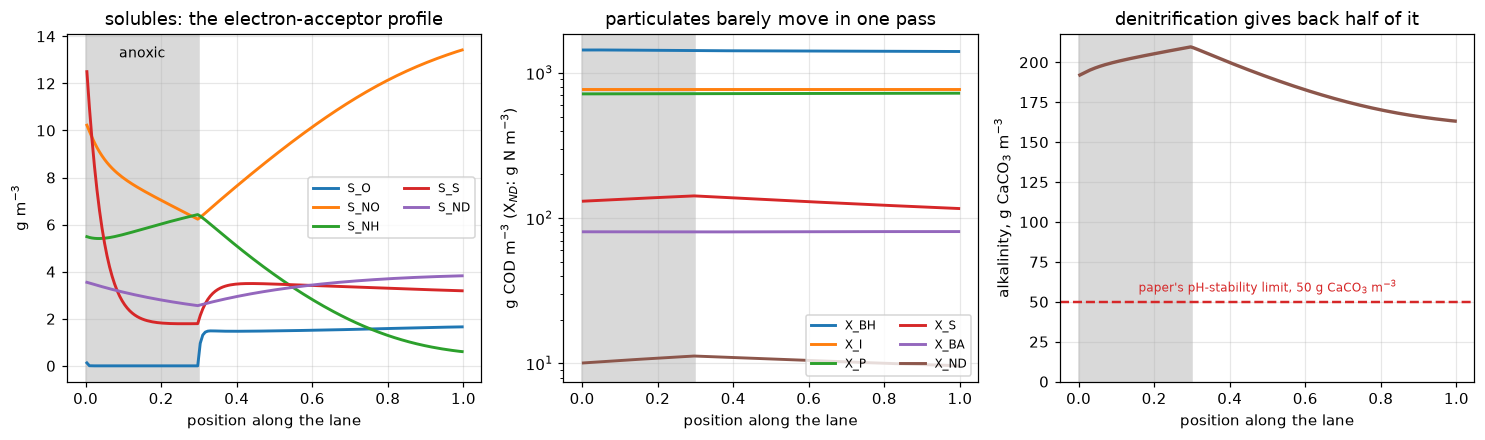

Denitrification consumes nitrate and releases oxygen demand in the unaerated
head end; nitrification rebuilds the nitrate and strips ammonia downstream.
Alkalinity rises through the anoxic zone and falls through the aerated one -
the behaviour the paper says column 13 was put in the model to predict.


In [8]:
S = lane()
c, c_in = S["c"], S["c_in"]
print(f"recycle fixed point in {S['outer']} iterations, Newton converged: {S['ok']}")
print(f"{'':6s}{'feed':>10s}{'lane inlet':>12s}{'lane outlet':>12s}")
for k in COMPS:
    print(f"{k:6s}{S['feed'][IX[k]]:10.3f}{c_in[IX[k]]:12.4f}{c[-1, IX[k]]:12.4f}")
print(f"\noxygen transfer rate {S['otr']:.1f} g O2 per m3 of lane per day")

fig, ax = plt.subplots(1, 3, figsize=(13.6, 4.1))
for k, col in (("S_O", "tab:blue"), ("S_NO", "tab:orange"), ("S_NH", "tab:green"),
               ("S_S", "tab:red"), ("S_ND", "tab:purple")):
    ax[0].plot(S["z"], c[:, IX[k]], lw=1.9, color=col, label=k)
ax[0].axvspan(0, 0.30, color="0.85", zorder=0)
ax[0].text(0.15, ax[0].get_ylim()[1] * 0.93, "anoxic", ha="center", fontsize=9)
ax[0].set(xlabel="position along the lane", ylabel="g m$^{-3}$",
          title="solubles: the electron-acceptor profile")
ax[0].legend(fontsize=8, ncol=2)

for k in ("X_BH", "X_I", "X_P", "X_S", "X_BA", "X_ND"):
    ax[1].plot(S["z"], c[:, IX[k]], lw=1.9, label=k)
ax[1].axvspan(0, 0.30, color="0.85", zorder=0)
ax[1].set(xlabel="position along the lane", ylabel="g COD m$^{-3}$ (X$_{ND}$: g N m$^{-3}$)",
          yscale="log", title="particulates barely move in one pass")
ax[1].legend(fontsize=8, ncol=2)

ax[2].plot(S["z"], c[:, IX["S_ALK"]] * 50.0, lw=2.2, color="tab:brown")
ax[2].axhline(50.0, color="tab:red", ls="--", lw=1.6)
ax[2].text(0.5, 56, "paper's pH-stability limit, 50 g CaCO$_3$ m$^{-3}$",
           fontsize=8, color="tab:red", ha="center")
ax[2].axvspan(0, 0.30, color="0.85", zorder=0)
ax[2].set(xlabel="position along the lane", ylabel="alkalinity, g CaCO$_3$ m$^{-3}$",
          ylim=(0, None), title="denitrification gives back half of it")
fig.tight_layout(); plt.show()

print("Denitrification consumes nitrate and releases oxygen demand in the unaerated")
print("head end; nitrification rebuilds the nitrate and strips ammonia downstream.")
print("Alkalinity rises through the anoxic zone and falls through the aerated one -")
print("the behaviour the paper says column 13 was put in the model to predict.")

## Validation

Five checks. The first three test the transcription without a solver anywhere
near them; the last two test the discretisation.

In [9]:
print("1. THE TWO COD RESIDUALS ARE EXACTLY THE PRINTED ROUNDING\n")
print("   Printed:   2.86  vs  20/7 =", sp.nsimplify(sp.Rational(20, 7)),
      "=", float(sp.Rational(20, 7)))
print("              4.57  vs  32/7 =", sp.nsimplify(sp.Rational(32, 7)),
      "=", float(sp.Rational(32, 7)))
print("   Differences:  2.86 - 20/7 =", sp.Rational(286, 100) - sp.Rational(20, 7),
      "      4.57 - 32/7 =", sp.Rational(457, 100) - sp.Rational(32, 7), "\n")

NU_EXACT = {j: dict(v) for j, v in NU.items()}
NU_EXACT[2]["S_NO"] = -(1 - Y_H) / (sp.Rational(20, 7) * Y_H)
NU_EXACT[2]["S_N2"] = -NU_EXACT[2]["S_NO"]
NU_EXACT[2]["S_ALK"] = (1 - Y_H) / (14 * sp.Rational(20, 7) * Y_H) - i_XB / 14
NU_EXACT[3]["S_O"] = -(sp.Rational(32, 7) - Y_A) / Y_A

res_exact = {law: continuity(law, NU_EXACT) for law in ("COD", "N", "charge")}
print("   Substituting 20/7 and 32/7 for the printed decimals:")
for law in ("COD", "N", "charge"):
    vals = [res_exact[law][j] for j in sorted(NU)]
    print(f"      {law:7s} residuals on all 8 processes: "
          f"{'all exactly zero' if all(v == 0 for v in vals) else vals}")
print("\n   So the printed matrix is continuous in COD, nitrogen and charge to the")
print("   last digit the typesetting allows, and the only defect in all 104 cells")
print("   is that two repeating fractions were printed to two decimals.")

1. THE TWO COD RESIDUALS ARE EXACTLY THE PRINTED ROUNDING

   Printed:   2.86  vs  20/7 = 20/7 = 2.857142857142857
              4.57  vs  32/7 = 32/7 = 4.571428571428571
   Differences:  2.86 - 20/7 = 1/350       4.57 - 32/7 = -1/700 

   Substituting 20/7 and 32/7 for the printed decimals:
      COD     residuals on all 8 processes: all exactly zero
      N       residuals on all 8 processes: all exactly zero
      charge  residuals on all 8 processes: all exactly zero

   So the printed matrix is continuous in COD, nitrogen and charge to the
   last digit the typesetting allows, and the only defect in all 104 cells
   is that two repeating fractions were printed to two decimals.


In [10]:
print("2. TEN PRINTED COEFFICIENTS RECOVERED FROM CONTINUITY ALONE\n")
print("   Delete a cell, solve the relevant balance for it, compare with the paper.")
print("   A single mis-read digit anywhere in the row would break this.\n")

targets = [(1, "S_O", "COD"), (1, "S_ALK", "charge"),
           (2, "S_NO", "COD"), (2, "S_ALK", "charge"),
           (3, "S_O", "COD"), (3, "S_NH", "N"), (3, "S_ALK", "charge"),
           (4, "X_ND", "N"), (5, "X_ND", "N"), (6, "S_ALK", "charge")]

n_exact, n_rounding = 0, 0
print(f"   {'j':>2} {'cell':<7}{'law':<8}{'as printed in Table 1':<34}"
      f"{'recovered minus printed':<26}verdict")
for j, cell, law in targets:
    x = sp.Symbol("x")
    trial = dict(NU[j]); trial[cell] = x
    if j == 2 and cell == "S_NO":
        trial["S_N2"] = -x                     # N continuity ties N2 to the nitrate
    sol = sp.solve(sum(trial[c] * gamma[law][c] for c in COMPS), x)[0]
    printed = stoi[cell][j - 1]                # the raw transcribed string
    diff = sp.simplify(sol - NU[j][cell])
    if diff == 0:
        verdict, n_exact = "identical", n_exact + 1
    else:
        verdict, n_rounding = "the 2.86 / 4.57 rounding", n_rounding + 1
    print(f"   {j:>2} {cell:<7}{law:<8}{printed:<34}"
          f"{sp.sstr(sp.nsimplify(diff)):<26}{verdict}")
print(f"\n   {n_exact} of {len(targets)} come back symbolically identical to the printed cell.")
print(f"   The other {n_rounding} differ only by the rounding of check 1:")
print(f"      process 2, S_NO : (Y_H-1)/(2860*Y_H), i.e. the 1/350 in 2.86")
print(f"      process 3, S_O  : -1/(700*Y_A),       i.e. the 1/700 in 4.57")

2. TEN PRINTED COEFFICIENTS RECOVERED FROM CONTINUITY ALONE

   Delete a cell, solve the relevant balance for it, compare with the paper.
   A single mis-read digit anywhere in the row would break this.

    j cell   law     as printed in Table 1             recovered minus printed   verdict
    1 S_O    COD     -(1-Y_H)/Y_H                      0                         identical
    1 S_ALK  charge  -i_XB/14                          0                         identical
    2 S_NO   COD     -(1-Y_H)/(2.86*Y_H)               (Y_H - 1)/(2860*Y_H)      the 2.86 / 4.57 rounding
    2 S_ALK  charge  (1-Y_H)/(14*2.86*Y_H)-i_XB/14     0                         identical
    3 S_O    COD     -(4.57-Y_A)/Y_A                   -1/(700*Y_A)              the 2.86 / 4.57 rounding
    3 S_NH   N       -i_XB-1/Y_A                       0                         identical
    3 S_ALK  charge  -i_XB/14-1/(7*Y_A)                0                         identical
    4 X_ND   N       i_XB-f_P*i_XP      

In [11]:
print("3. THE PAPER'S OWN EQUATION (3) IS A FREE CROSS-CHECK\n")
print("   Equation (3) writes out r_2 = v21*rho_1 + v22*rho_2 + v27*rho_7 in full,")
print("   typeset separately from the matrix. Building it from the transcribed")
print("   matrix column and the transcribed rate rows must reproduce it exactly.\n")

syms = dict(SYMS)
syms.update({s: sp.Symbol(s) for s in
             ("S_S", "S_O", "S_NO", "S_NH", "S_ND", "X_S", "X_BH", "X_BA", "X_ND",
              "mu_hat_H", "mu_hat_A", "K_S", "K_OH", "K_NO", "K_NH", "K_OA",
              "b_H", "b_A", "k_a", "k_h", "K_X", "eta_g", "eta_h")})
RHO = {int(r.j): sp.sympify(r.rate, locals=syms) for r in rates.itertuples()}

built = sum(NU[j]["S_S"] * RHO[j] for j in (1, 2, 7))

# Equation (3) exactly as printed on journal page 507, read from the 600 dpi render
S_S, S_O, S_NO, X_S, X_BH = (syms[k] for k in ("S_S", "S_O", "S_NO", "X_S", "X_BH"))
K_S, K_OH, K_NO, K_X = (syms[k] for k in ("K_S", "K_OH", "K_NO", "K_X"))
mu_H, eta_g, eta_h, k_h = (syms[k] for k in ("mu_hat_H", "eta_g", "eta_h", "k_h"))
eq3 = (-1 / Y_H * mu_H * (S_S / (K_S + S_S)) * (S_O / (K_OH + S_O)) * X_BH
       - 1 / Y_H * mu_H * (S_S / (K_S + S_S)) * (K_OH / (K_OH + S_O))
         * (S_NO / (K_NO + S_NO)) * eta_g * X_BH
       + k_h * (X_S / X_BH) / (K_X + (X_S / X_BH))
         * ((S_O / (K_OH + S_O)) + eta_h * (K_OH / (K_OH + S_O)) * (S_NO / (K_NO + S_NO)))
         * X_BH)

delta_eq3 = sp.simplify(built - eq3)
print("   column 2 of the matrix x the rate column, minus equation (3):", delta_eq3)
print("   ->", "identical" if delta_eq3 == 0 else "MISMATCH")
print("\n   That is three matrix cells and three rate rows confirmed against a part")
print("   of the paper set in a different place, at no cost.")

3. THE PAPER'S OWN EQUATION (3) IS A FREE CROSS-CHECK

   Equation (3) writes out r_2 = v21*rho_1 + v22*rho_2 + v27*rho_7 in full,
   typeset separately from the matrix. Building it from the transcribed
   matrix column and the transcribed rate rows must reproduce it exactly.

   column 2 of the matrix x the rate column, minus equation (3): 0
   -> identical

   That is three matrix cells and three rate rows confirmed against a part
   of the paper set in a different place, at no cost.


In [12]:
print("4. THE REACTOR CONSERVES WHAT THE MATRIX CONSERVES, AND LEAKS WHAT IT LEAKS\n")
print("   At steady state the flux of a conserved quantity through the lane can only")
print("   change by what crosses the boundary - here, the oxygen transferred in.")
print("   The fluxes come from the pymrm convection operator itself.\n")

g_num = {law: np.array([float(gamma[law][c].subs(STOICH)) for c in COMPS])
         for law in ("COD", "N", "charge")}
NU_M       = numeric_nu()
NU_M_EXACT = numeric_nu(NU_EXACT)


def balance(sol, law):
    w = g_num[law]
    src = -sol["otr"] if law == "COD" else 0.0      # gamma_COD(S_O) = -1
    return float(sol["flux_in"] @ w) + src - float(sol["flux_out"] @ w)


print(f"   {'matrix':<22}{'n':>5}{'COD leak':>15}{'predicted':>15}"
      f"{'N':>12}{'charge':>12}")
rows = {}
for tag, M in (("printed 2.86 / 4.57", NU_M), ("exact 20/7 / 32/7", NU_M_EXACT)):
    for n in (75, 150, 300):
        s = lane(nu_m=M, n=n)
        r_int = rho(s["c"], P).T @ s["dz"]           # integral of each rate over the lane
        pred = -float((g_num["COD"] @ M.T) @ r_int)  # leak the matrix itself predicts
        b = {law: balance(s, law) for law in ("COD", "N", "charge")}
        rows[(tag, n)] = (b, pred, s)
        print(f"   {tag:<22}{n:>5}{b['COD']:15.6e}{pred:15.6e}"
              f"{b['N']:12.2e}{b['charge']:12.2e}")

b150, pred150, s150 = rows[("printed 2.86 / 4.57", 150)]
bx150, _, _ = rows[("exact 20/7 / 32/7", 150)]
worst_n = max(abs(b["N"]) for b, _, _ in rows.values())
worst_q = max(abs(b["charge"]) for b, _, _ in rows.values())
print(f"\n   Nitrogen closes to {worst_n:.0e} and charge to {worst_q:.0e} g m-3 d-1, against")
print(f"   an oxygen demand of {s150['otr']:.0f} g m-3 d-1 - eleven to fifteen orders of")
print("   magnitude down, i.e. machine precision. That is a genuine test of the")
print("   discretisation: the upwind boundary fluxes and the summed source term have")
print("   to cancel exactly, and they do at every grid.")
print(f"\n   COD does not close. It leaks {b150['COD']:.4f} g O2 m-3 d-1. The matrix's own")
print(f"   two residuals predict that leak to {abs(b150['COD'] - pred150) / abs(pred150):.0e} relative, so it is")
print("   stoichiometric and not numerical - and it is grid independent, which")
print("   numerical error would not be.")
print(f"\n   Substituting 20/7 and 32/7 closes the same lane to {abs(bx150['COD']):.0e}, better by a")
print(f"   factor of {abs(b150['COD'] / bx150['COD']):.0e}, with nothing else changed anywhere.")
print(f"   In practice the printed rounding mis-states the oxygen requirement by")
print(f"   {100 * abs(b150['COD']) / s150['otr']:.3f} % - irrelevant for design, and decisive as evidence that")
print("   the transcription is right.")

4. THE REACTOR CONSERVES WHAT THE MATRIX CONSERVES, AND LEAKS WHAT IT LEAKS

   At steady state the flux of a conserved quantity through the lane can only
   change by what crosses the boundary - here, the oxygen transferred in.
   The fluxes come from the pymrm convection operator itself.

   matrix                    n       COD leak      predicted           N      charge


   printed 2.86 / 4.57      75   2.070697e-01   2.070697e-01    0.00e+00   -1.42e-14


   printed 2.86 / 4.57     150   2.071576e-01   2.071576e-01   -1.36e-12    2.84e-14


   printed 2.86 / 4.57     300   2.074305e-01   2.074305e-01   -1.59e-12   -2.84e-14


   exact 20/7 / 32/7        75   0.000000e+00  -3.215250e-14    0.00e+00    1.42e-14


   exact 20/7 / 32/7       150  -7.275958e-12  -3.217009e-14    0.00e+00    3.55e-14


   exact 20/7 / 32/7       300  -1.091394e-11  -3.224349e-14   -1.36e-12    0.00e+00

   Nitrogen closes to 2e-12 and charge to 4e-14 g m-3 d-1, against
   an oxygen demand of 652 g m-3 d-1 - eleven to fifteen orders of
   magnitude down, i.e. machine precision. That is a genuine test of the
   discretisation: the upwind boundary fluxes and the summed source term have
   to cancel exactly, and they do at every grid.

   COD does not close. It leaks 0.2072 g O2 m-3 d-1. The matrix's own
   two residuals predict that leak to 6e-11 relative, so it is
   stoichiometric and not numerical - and it is grid independent, which
   numerical error would not be.

   Substituting 20/7 and 32/7 closes the same lane to 7e-12, better by a
   factor of 3e+10, with nothing else changed anywhere.
   In practice the printed rounding mis-states the oxygen requirement by
   0.032 % - irrelevant for design, and decisive as evidence that
   the transcription is right.


In [13]:
print("5. GRID CONVERGENCE OF THE LANE\n")
ref = lane(n=2400)["c"][-1]
KEY = ["S_S", "S_NO", "S_NH", "S_ND", "S_ALK", "S_N2", "X_S"]
print(f"   {'n':>6}{'S_NH out':>12}{'S_NO out':>12}{'alk out':>12}{'worst rel err':>15}{'ratio':>8}")
prev = None
for n in (75, 150, 300, 600):
    s = lane(n=n)["c"][-1]
    e = max(abs(s[IX[k]] - ref[IX[k]]) / abs(ref[IX[k]]) for k in KEY)
    ratio = "" if prev is None else f"{prev / e:8.2f}"
    print(f"   {n:>6}{s[IX['S_NH']]:12.5f}{s[IX['S_NO']]:12.5f}"
          f"{s[IX['S_ALK']] * 50:12.4f}{e:15.3e}{ratio}")
    prev = e
print("\n   Error is measured on the outlet solubles against an n = 2400 reference.")
print("   Ratios sit near 2: first order, which is what upwind convection gives.")
print("   Effluent ammonia sets the worst case because it is a small difference of")
print("   two large numbers - 15.5 g N m-3 arrives and almost all of it is nitrified.")
print("   The conservation checks above hold at every n, as they must: a conservative")
print("   discretisation conserves on a coarse grid too, it is just less accurate.")

5. GRID CONVERGENCE OF THE LANE



        n    S_NH out    S_NO out     alk out  worst rel err   ratio


       75     0.62056    13.40935    163.2543      5.631e-02


      150     0.60457    13.42007    163.1589      2.908e-02    1.94


      300     0.59530    13.40000    163.1975      1.331e-02    2.18


      600     0.59081    13.38804    163.2242      5.659e-03    2.35

   Error is measured on the outlet solubles against an n = 2400 reference.
   Ratios sit near 2: first order, which is what upwind convection gives.
   Effluent ammonia sets the worst case because it is a small difference of
   two large numbers - 15.5 g N m-3 arrives and almost all of it is nitrified.
   The conservation checks above hold at every n, as they must: a conservative
   discretisation conserves on a coarse grid too, it is just less accurate.


## What pymrm adds

Nothing to the matrix. The matrix is the paper's contribution and it is exact;
the page's job was to reproduce it and show that it closes.

What the reactor adds is the **use** of the one column the paper describes as
optional. It says of alkalinity that "although its inclusion is not essential, it is
desirable", gives a threshold — below about 50 g m⁻³ as CaCO₃ the pH goes
unstable — and then never computes where a plant sits relative to it. The column
is there; the design question it answers is not asked.

It can be asked directly, and charge continuity settles the arithmetic before any
solver runs. Rearranging $\sum_i \gamma^\text{charge}_i \nu_{ij}=0$ for the
alkalinity cell gives

$$ \nu_{ALK,j} = \tfrac{1}{14}\left(\nu_{NH,j} - \nu_{NO,j}\right), $$

so moving one gram of N from ammonium to nitrate costs $2/14$ mol of alkalinity
and removing one gram of nitrate returns $1/14$. **Denitrification recovers
exactly half of what nitrification destroys** — 3.571 against 7.143 g CaCO₃ per
g N, a ratio of exactly 2 with no parameter in it. (Growth also assimilates
ammonium, which removes a further $i_{XB}/14$ mol per gram of biomass COD formed;
that term is common to all three growth rows and is separate from the two above.)

Everything below is that identity, put through a reactor with real switching
functions and a real recycle.

from charge continuity alone: nitrification destroys 7.1429 g CaCO3 per g N
                              denitrification returns 3.5714 g CaCO3 per g N
                              ratio 2.000000, exactly 2

and the check that this really is what the printed matrix says:
   nitrification (process 3, N produced)          -1/7 mol per g N  =  -7.1429 g CaCO3
   denitrification (process 2, N consumed)        1/14 mol per g N  =  +3.5714 g CaCO3
   (2.86 in the denitrification cell cancels exactly, so that row does not
    even feel the rounding - which is why charge closed for the printed matrix)



linearity check: outlet alkalinity moves 25.0000 g CaCO3 m-3 per mol m-3
of raw-water alkalinity, against 25.0000 predicted by the 1:1 blend



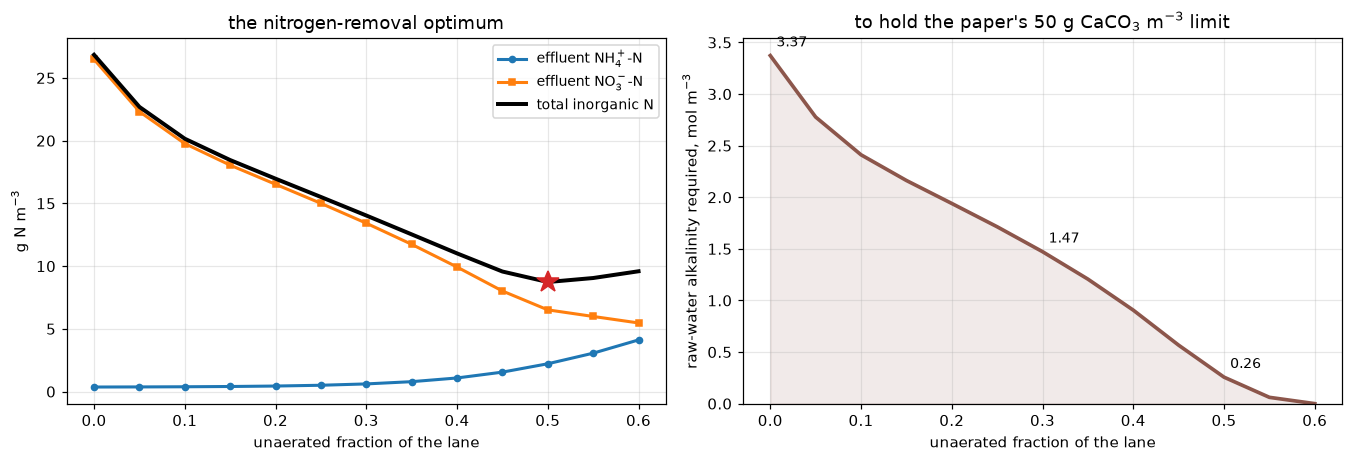

total inorganic nitrogen is lowest at an unaerated fraction of 0.50, at 8.73 g N m-3,
against 26.84 with no anoxic zone at all - a 67 % reduction.
Beyond that, nitrification runs out of aerated volume: effluent ammonia goes
from 2.22 to 4.12 g N m-3 over the last 0.10 of the sweep.

And the alkalinity column earns its place. Reading the second panel at three
points, the raw-water alkalinity this lane needs in order to stay above the
paper's own pH-stability threshold is
       0 % unaerated ->  3.37 mol m-3 (  169 g CaCO3 m-3)
      30 % unaerated ->  1.47 mol m-3 (   74 g CaCO3 m-3)
      50 % unaerated ->  0.26 mol m-3 (   13 g CaCO3 m-3)

The lane's own influent carries 6 mol m-3, so it has margin either way; a
wastewater at half that would be fine with a 30 % anoxic zone and marginal
without one. Past about 0.60 unaerated the requirement reaches zero, but
only because nitrification is by then incomplete - the alkalinity is spared
because the ammonia is not removed, which is not a d

In [14]:
# alkalinity per gram of nitrogen converted, straight from charge continuity
nu_alk = lambda d_NH, d_NO: sp.Rational(1, 14) * (d_NH - d_NO)
ALK_N_nit = float(-nu_alk(-1, +1)) * 50.0    # NH4+ -> NO3-, one g N
ALK_N_den = float(+nu_alk(0, -1)) * 50.0     # NO3- -> N2,   one g N
print(f"from charge continuity alone: nitrification destroys {ALK_N_nit:.4f} g CaCO3 per g N")
print(f"                              denitrification returns {ALK_N_den:.4f} g CaCO3 per g N")
print(f"                              ratio {ALK_N_nit / ALK_N_den:.6f}, exactly 2\n")
print("and the check that this really is what the printed matrix says:")
for j, sign, name in ((3, +1, "nitrification (process 3, N produced)"),
                      (2, -1, "denitrification (process 2, N consumed)")):
    # strip the i_XB/14 assimilation term, then divide by the nitrate turned over
    per_N = sp.simplify((NU[j]["S_ALK"] + i_XB / 14) / (sign * NU[j]["S_NO"]))
    print(f"   {name:<41}{sp.sstr(sp.nsimplify(per_N)):>10} mol per g N"
          f"  = {float(per_N) * 50:+8.4f} g CaCO3")
print("   (2.86 in the denitrification cell cancels exactly, so that row does not")
print("    even feel the rounding - which is why charge closed for the printed matrix)")
print()

f_grid = np.linspace(0.0, 0.60, 13)
out = np.array([lane(n=100, f_anox=f)["c"][-1] for f in f_grid])
NH, NO, ALK = out[:, IX["S_NH"]], out[:, IX["S_NO"]], out[:, IX["S_ALK"]] * 50.0
TN = NH + NO

# alkalinity is a passive tracer of the nitrogen conversions, so the outlet moves
# 25 g CaCO3/m3 per mol/m3 of raw-water alkalinity (the 1:1 blend halves it).
# Checked directly below rather than assumed.
chk = lane(n=100, f_anox=0.30, c_feed=feed(alk=0.5))["c"][-1, IX["S_ALK"]] * 50.0
slope = (ALK[6] - chk) / (6.0 - 3.0)
print(f"linearity check: outlet alkalinity moves {slope:.4f} g CaCO3 m-3 per mol m-3")
print(f"of raw-water alkalinity, against 25.0000 predicted by the 1:1 blend\n")
need = np.maximum(6.0 - (ALK - 50.0) / 25.0, 0.0)  # raw-water alkalinity needed

fig, ax = plt.subplots(1, 2, figsize=(12.4, 4.3))
ax[0].plot(f_grid, NH, "o-", lw=2, ms=4, label="effluent NH$_4^+$-N")
ax[0].plot(f_grid, NO, "s-", lw=2, ms=4, label="effluent NO$_3^-$-N")
ax[0].plot(f_grid, TN, "-", lw=2.6, color="k", label="total inorganic N")
i_min = int(np.argmin(TN))
ax[0].plot(f_grid[i_min], TN[i_min], "*", ms=15, color="tab:red", zorder=5)
ax[0].set(xlabel="unaerated fraction of the lane", ylabel="g N m$^{-3}$",
          title="the nitrogen-removal optimum")
ax[0].legend(fontsize=9)

ax[1].plot(f_grid, need, "-", lw=2.4, color="tab:brown")
ax[1].fill_between(f_grid, 0, need, color="tab:brown", alpha=0.12)
ax[1].set(xlabel="unaerated fraction of the lane",
          ylabel="raw-water alkalinity required, mol m$^{-3}$",
          title="to hold the paper's 50 g CaCO$_3$ m$^{-3}$ limit", ylim=(0, None))
for f in (0.0, 0.30, 0.50):
    k = int(np.argmin(abs(f_grid - f)))
    ax[1].annotate(f"{need[k]:.2f}", (f_grid[k], need[k]), textcoords="offset points",
                   xytext=(4, 6), fontsize=9)
fig.tight_layout(); plt.show()

print(f"total inorganic nitrogen is lowest at an unaerated fraction of "
      f"{f_grid[i_min]:.2f}, at {TN[i_min]:.2f} g N m-3,")
print(f"against {TN[0]:.2f} with no anoxic zone at all - a {100 * (1 - TN[i_min] / TN[0]):.0f} % reduction.")
print(f"Beyond that, nitrification runs out of aerated volume: effluent ammonia goes")
print(f"from {NH[i_min]:.2f} to {NH[-1]:.2f} g N m-3 over the last {f_grid[-1] - f_grid[i_min]:.2f} of the sweep.\n")
print("And the alkalinity column earns its place. Reading the second panel at three")
print("points, the raw-water alkalinity this lane needs in order to stay above the")
print("paper's own pH-stability threshold is")
for f in (0.0, 0.30, 0.50):
    k = int(np.argmin(abs(f_grid - f)))
    print(f"   {100 * f_grid[k]:5.0f} % unaerated ->{need[k]:6.2f} mol m-3 "
          f"({50 * need[k]:5.0f} g CaCO3 m-3)")
print(f"\nThe lane's own influent carries 6 mol m-3, so it has margin either way; a")
print(f"wastewater at half that would be fine with a 30 % anoxic zone and marginal")
print(f"without one. Past about {f_grid[np.argmax(need <= 0)]:.2f} unaerated the requirement reaches zero, but")
print("only because nitrification is by then incomplete - the alkalinity is spared")
print("because the ammonia is not removed, which is not a design anyone wants.")

In [15]:
print("The ammonification coefficient, at both values Table 4 prints\n")
for label, ka in (("k_a = 0.016 (the row carrying the model's symbol)", 0.016),
                  ("k_A = 0.080 (the undefined twentieth row)", 0.080)):
    p = dict(P); p["k_a"] = ka
    s = lane(n=100, p=p)["c"][-1]
    print(f"   {label:<50} S_ND {s[IX['S_ND']]:6.3f}  S_NH {s[IX['S_NH']]:6.3f}"
          f"  S_NO {s[IX['S_NO']]:7.3f}  alk {s[IX['S_ALK']] * 50:7.2f}")
print("\n   The choice moves soluble organic nitrogen appreciably and effluent")
print("   inorganic nitrogen very little, because ammonification only decides how")
print("   fast an already-small pool turns over. It does not touch continuity at all -")
print("   no kinetic parameter appears in any of the checks above.")

report_agreement("J4.8", {
    "charge_residuals_all_zero": float(all(res["charge"][j] == 0 for j in sorted(NU))),
    "nitrogen_residuals_all_zero": float(all(res["N"][j] == 0 for j in sorted(NU))),
    "cod_residual_p2": float(res["COD"][2].subs(STOICH)),
    "cod_residual_p3": float(res["COD"][3].subs(STOICH)),
    "cod_residuals_zero_with_exact_factors": float(
        all(res_exact["COD"][j] == 0 for j in sorted(NU))),
    "coefficients_recovered_identically": float(n_exact),
    "coefficients_recovered_up_to_rounding": float(n_rounding),
    "eq3_cross_check": float(delta_eq3 == 0),
    "reactor_charge_balance": float(abs(b150["charge"])),
    "reactor_nitrogen_balance": float(abs(b150["N"])),
    "reactor_cod_leak": float(abs(b150["COD"])),
    "reactor_cod_leak_vs_prediction": float(abs(b150["COD"] - pred150) / abs(pred150)),
    "reactor_cod_leak_exact_factors": float(abs(bx150["COD"])),
    "reactor_cod_leak_fraction_of_otr": float(abs(b150["COD"]) / s150["otr"]),
    "tn_reduction_at_optimum": float(1 - TN[i_min] / TN[0]),
})

The ammonification coefficient, at both values Table 4 prints



   k_a = 0.016 (the row carrying the model's symbol)  S_ND  3.823  S_NH  0.613  S_NO  13.422  alk  163.18


   k_A = 0.080 (the undefined twentieth row)          S_ND  0.805  S_NH  1.033  S_NO  15.931  alk  155.72

   The choice moves soluble organic nitrogen appreciably and effluent
   inorganic nitrogen very little, because ammonification only decides how
   fast an already-small pool turns over. It does not touch continuity at all -
   no kinetic parameter appears in any of the checks above.
Agreement metrics for J4.8:
  charge_residuals_all_zero             = 1
  nitrogen_residuals_all_zero           = 1
  cod_residual_p2                       = -0.00077422
  cod_residual_p3                       = -0.010204
  cod_residuals_zero_with_exact_factors = 1
  coefficients_recovered_identically    = 8
  coefficients_recovered_up_to_rounding = 2
  eq3_cross_check                       = 1
  reactor_charge_balance                = 2.8422e-14
  reactor_nitrogen_balance              = 1.3642e-12
  reactor_cod_leak                      = 0.20716
  reactor_cod_leak_vs_prediction        = 6.1188e-11
 

{'page': 'J4.8',
 'metrics': {'charge_residuals_all_zero': 1.0,
  'nitrogen_residuals_all_zero': 1.0,
  'cod_residual_p2': -0.0007742183488853016,
  'cod_residual_p3': -0.01020408163265306,
  'cod_residuals_zero_with_exact_factors': 1.0,
  'coefficients_recovered_identically': 8.0,
  'coefficients_recovered_up_to_rounding': 2.0,
  'eq3_cross_check': 1.0,
  'reactor_charge_balance': 2.842170943040401e-14,
  'reactor_nitrogen_balance': 1.3642420526593924e-12,
  'reactor_cod_leak': 0.2071576023226953,
  'reactor_cod_leak_vs_prediction': 6.118838108692497e-11,
  'reactor_cod_leak_exact_factors': 7.275957614183426e-12,
  'reactor_cod_leak_fraction_of_otr': 0.0003175690548549939,
  'tn_reduction_at_optimum': 0.6746250048765576}}

**What this page does not establish.** No comparison with a
measurement, anywhere, and that is a property of the source: the abbreviated
report contains no worked example, no calibrated plant and no dataset. Its one
figure with data in it is borrowed from Ekama et al. (1986) to show a
*measurement procedure*. So `J4.8` validates a **transcription and its internal
consistency**, not a prediction — and it says so rather than manufacturing a
comparison.

The reactor inherits every one of the paper's own restrictions (constant
temperature, constant near-neutral pH, no inorganic suspended solids) and adds
some of its own: plug flow with no axial dispersion, a settler treated as a
perfect separation point, mixed-liquor solids imposed at the inlet rather than
set by a sludge age, and an operating point chosen by us. The trade-off curves
above are therefore a demonstration of what the matrix implies, not a design
calculation for any real plant.

And the continuity check has a boundary worth naming. It tests the matrix against
the component *definitions*. It cannot tell you whether $\rho_7$'s hydrolysis
saturation is the right functional form, whether $\eta_g$ is 0.6 or 1.0, or
whether decay really is independent of electron acceptor. Continuity constrains
stoichiometry; it says nothing about kinetics.

## Reuse

**The continuity test is the reusable part, and it is not specific to ASM1.**
Any Petersen-matrix model — ASM2, ASM3, ADM1, a mixed-culture bioprocess written
in the same format — carries composition vectors that must annihilate every row.
`continuity(law)` above needs only `gamma[law]` and the matrix. Run it *before*
you run the model: it catches sign errors, dropped terms and transcription slips
that a simulation will happily absorb into a slightly wrong oxygen demand.

**Solving continuity for a missing cell is how you should fill one in.** Check 2
above recovers ten printed coefficients from the balances. The same call fills a
genuinely unknown coefficient, which is the standard way to extend one of these
matrices with a new process: write the cells the process definition fixes, then
let the three balances supply the electron acceptor, the ammonium and the
alkalinity.

**Add S_N2 whenever nitrate is reduced.** ASM1's nitrogen balance cannot close
without it, and the missing $(1-Y_H)/(2.86\,Y_H)$ — between 0.16 and 0.41 g N per
gram of biomass grown anoxically, over Table 4's yield range — is easy to mistake
for a bug in your own code.

**The pymrm piece is a reaction network on a 1-D convective grid** —
`construct_convflux_upwind` + `construct_div` for transport, `NumJac(shape)` +
`newton` for the steady state. `NumJac(shape)` with no `axes_diagonals` is right
here because the source is pointwise; add `axes_diagonals=[0]` the moment a
source term reads a neighbouring cell (a biofilm flux, a settling velocity).
Swapping ASM1 for any other network means replacing `rho` and the matrix, and
nothing else.

**Two traps met while building this.** The recycle fixed point contracts at
$R/(1+R)$, so it needs about 55 iterations at $R = 2$; over-relaxing it by
$(1+R)$ looks like the obvious Newton acceleration and diverges, because the fast
components ($S_S$, $S_O$, $S_{NH}$) have essentially no memory of the inlet and
their contraction factor is nothing like $R/(1+R)$. And take the boundary fluxes
from the convection operator rather than from the end cell values: with the
zero-gradient outlet the face value is extrapolated, and using `c[-1]` instead
puts a spurious $10^{-3}$ into an otherwise machine-precision balance.

**Related pages.** `J4.7` (enzyme kinetics in a pellet), `I1.2` (a reaction
network with strong switching behaviour), [`C2.1`](../C2.1-xu-froment-smr/)
(a multi-reaction network validated against measurements rather than against
itself).

**Cite the source, not this page:** Henze, M., Grady, C. P. L. Jr, Gujer, W.,
Marais, G. v. R. and Matsuo, T., *A general model for single-sludge wastewater
treatment systems*, Water Research **21**(5), 505–515 (1987),
doi:10.1016/0043-1354(87)90058-3. The full report is IAWPRC Scientific and
Technical Report No. 1.